# Direct detection with trans-stilbene 

Calculating electron recoil scattering rate in trans-stilbene, using the LCAO wavefunctions for the ground and excited states derived in arXiv:2103.08601. The $\langle f_s^2 | n \ell m \rangle$ coefficients used in this notebook are taken from 2021 data, of $f_s^2(\vec q)$ tabulated on a spherical grid of $\vec q$ points. Enough data was available to reconstruct the $s_1$, $s_2$, $s_5$ and $s_8$ transition form factors using a discrete spherical harmonic transformation. 

## Tabulated Form Factors

Excited states $s_3$ and $s_4$ are not included here, even though they contribute non-negligibly to the rate. The $s_{2,5,8}$ transitions $f_s^2(\vec q)$ were evaluated at polar angles $\theta = 30^\circ, 45^\circ, 60^\circ, 75^\circ, 90^\circ$ on a five-degree grid of $\phi = 0, 5^\circ, 10^\circ, \ldots, 175^\circ$. The form factors vanish at $\theta = 0$, and they are symmetric under $180^\circ$ rotations about the $z$ axis, and under central inversion symmetry $\vec q \rightarrow - \vec q$. The $\langle f_s^2 | n \ell m \rangle$ coefficients were calculated by interpolating $f_s^2(\vec q)$ in $\theta$ to generate better coverage in the polar angle, then performing a discrete spherical harmonic transformation at each fixed value of $|\vec q|$, to extract a 1d function of $q = |\vec q|$ for each $(\ell m)$ mode, $\langle f_s^2 | \ell m \rangle$. The $s_{3,4}$ transitions are not included simply because they were only tabulated with detail at $\theta = 90^\circ$. As a result, the $s_{2,5,8}$ transitions here should be thought of as a placeholder for the systematic error in neglecting the higher excited states. 

From arXiv:2103.08601, the $s_1$ transition always provides the dominant component of the scattering rate, at least for DM masses $m_\chi \leq 100$ MeV. The 2021 data tabulated $f_s^2(\vec q)$ on a five-degree angular grid in $\theta = 5^\circ, 10^\circ, \ldots, 90^\circ$ and in $\phi$. 

The 2021 data was produced over approximately two weeks of non-consecutive cluster time. In the future, we expect it to be much faster to generate $f_s^2(\vec q)$ from standard physical chemistry codes, using gaussian-type orbital basis functions (GTO). The analysis pipeline would calculate $f_s(\vec q)$ from the ground state and final state electronic wavefunctions in the GTO basis, using some analytic results to simplify the integrals, to tabulate $f_s(\vec q)$ on a spherical grid of points. Then, the coefficients $\langle f_s^2 | n \ell m \rangle$ can be found very quickly by performing discrete transforms on the squared $f_s(\vec q)$ data. 

## Crystal Form Factors 

The unit cell of the crystal contains four molecules of trans-stilbene, rotated relative to the crystal $z$ axis (defined in 2103.08601):
$$f_{crys}^2(\vec q) = \sum_{i = 1..4} \mathcal R_i \cdot f_s^2(\vec q),$$
for four rotation operators $\mathcal R_i$ acting on the molecular form factors. 
Aria has applied these rotations to the molecular $\langle f_s^2 | n \ell m \rangle$ coefficients, adding the results together into a single set of $\langle f_{crys}^2 | n \ell m \rangle$, the momentum form factor for one unit cell of the crystal. The total scattering rate, for a detector of mass $M_T$, is proportional to the number of unit cells: 
$$N_{\rm cell} = N_A \frac{M_T}{4 \cdot m_{mol}} = N_A \frac{M_T}{721.0\ \rm g}, $$
where $N_A = 6.022 \cdot 10^{23}$ is Avogadro's number. 

## Tabulated Partial Rate Matrix 

The partial rate matrix $K^{(\ell)}_{m m'}$ is tabulated in `tstilbene_mK.hdf5`, for various DM masses $m_\chi = 2, 3, 5, 10, \ldots, 100$ MeV, for $F_{DM} = (\alpha m_e / q)^{2 n}$ with $n = 0, 2$, for four of the excited states: $s_1$, $s_2$, $s_5$, and $s_8$. These $K^{(\ell)}$ are for the TSB crystal, with the 2103.08601 coordinate system ($z = b$, etc.). 

### This Notebook

Predicts the time dependent scattering rate for a crystal, for arbitrarily many days. Largely copied from the monster notebook `cubeRotate.ipynb`, but without including the uncertainties on the Fermilab cube geometries. 


In [1]:
import math
import numpy as np
# import numba
import scipy.special as spf
import scipy.interpolate as interp
# import vegas # numeric integration
# import gvar # gaussian variables; for vegas
import time
import quaternionic as qnc # For rotations
# import spherical #For Wigner D matrix
# import csv # file IO for projectFnlm
# import os.path
import h5py # database format for mathcalI arrays
# import importlib
# from sympy.combinatorics import Permutation
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as clr
plt.rc('text', usetex=True)

# sys.path.insert(0,'../') #load the local version of vsdm

import vsdm
from vsdm.units import *
from vsdm.utilities import *
# from vsdm import McalK

import datetime as dts #for calendar functions
from astropy.coordinates import SkyCoord, Galactic, ICRS
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import solar_system_ephemeris, EarthLocation
from astropy.coordinates import get_body_barycentric, get_body
from astropy.coordinates import CartesianRepresentation, CartesianDifferential

import earthspeed as ethp
from earthspeed import Windfinder

diffM, diffV = vsdm.testG_lm(5, -3, printout=False)
if np.abs(diffV) < 1e-14:
    print("testing 'spherical' and WignerG: PASS")
else:
    print("testing 'spherical' and WignerG: FAIL")
    print("check the version number for 'spherical', and run testD_lm()")
print("vsdm", vsdm.__version__)
print("earthspeed", ethp.__version__)

deg = np.pi/180
unisize = 3.5

testing 'spherical' and WignerG: PASS
vsdm 0.4.4
earthspeed 1.2


In [2]:
### Quaternion rotation
# finding the rotation that moves a 'z hat' unit vector to point towards (theta, phi)

def getQ(theta, phi):
    axisphi = phi + np.pi/2 #stationary under R
    axR = theta/2 
    qr = np.cos(axR)
    qi = np.sin(axR) * np.cos(axisphi)
    qj = np.sin(axR) * np.sin(axisphi)
    qk = 0. 
    return qnc.array(qr, qi, qj, qk)


def ix_thetaphi(theta, phi):
    return thetaphilist.index((theta, phi))


def getRcrl(Uvec, Fvec, gamma): 
    # U points up 
    # F points horizontally towards CCD
    # gamma is CCD poisition (on horizon) wrt north horizon
    Uhat = Uvec / np.linalg.norm(Uvec)
    zhat = np.array([0, 0, 1])
    nUvec = np.cross(Uhat, zhat) 
    if np.linalg.norm(nUvec) == 0:
        nUhat = np.array([1, 0, 0])
    else:
        nUhat = nUvec / np.linalg.norm(nUvec)
    alphaU = np.arccos(Uhat @ zhat)
    nU = qnc.array([0] + [qi for qi in nUhat])
    QrU = np.cos(0.5*alphaU) * qnc.array(1, 0, 0, 0) + np.sin(0.5*alphaU) * nU
    # act with qrU on U: returns zhat.
    # act with qrU on F:
    Fhat = Fvec / np.linalg.norm(Fvec)
    nF = qnc.array([0] + [qi for qi in Fhat])
    RuF = QrU * nF / QrU
    RuFhat = RuF.vector # just the imaginary part of RuF: a 3d vector
    # get azimuthal coordinate of RuF:
    is_one, thetaRuF, phiRuF = cart_to_sph(RuFhat)
    # difference between phiRuF and gamma: 
    alphaF = (gamma - phiRuF) % (2*np.pi) 
    # rotate RuF about +z axis to point towards CCD (at gamma):
    QrF = qnc.array(np.cos(0.5*alphaF), 0, 0, np.sin(0.5*alphaF))
    Qrcl = QrF * QrU
    return Qrcl

def rotateBy(qR, v):
    # rotate a vector v (or array of vectors) by rotation operator qR
    return qR * v / qR

def fRMS(R_list):
    Rbar = np.mean(R_list) 
    Rt = np.array(R_list)
    diff_sq = (Rt - Rbar)**2
    root_mean_sq = np.sqrt(np.mean(diff_sq))
    return root_mean_sq / Rbar

def chi2norm(R_list):
    Rbar = np.mean(R_list) 
    Rt = np.array(R_list)
    diff_sq = (Rt - Rbar)**2
    root_mean_sq = np.sqrt(np.mean(diff_sq))
    return root_mean_sq**2 / Rbar
 
#

In [3]:
### TRANS-STILBENE FORM FACTORS: s1, s2, s5, s8

"""Definition of the Q and V basis functions:"""
# (these should not be changed, without also changing McalK)

QMAX = 24*keV # Global value for q0=qMax for wavelets
Qbasis = dict(u0=QMAX, type='wavelet', uMax=QMAX)

VMAX = 820.*km_s # Global value for v0=vMax for wavelets
Vbasis = dict(u0=VMAX, type='wavelet', uMax=VMAX)

DeltaE = {}
DeltaE['s1'] = 4.24*eV
DeltaE['s2'] = 4.788*eV
DeltaE['s5'] = 5.791*eV
DeltaE['s8'] = 6.439*eV

"""When creating tstilbene_mK.hdf5, this format was used for the model labels:"""

ellMax = 24
nvMax = 511
nqMax = 1023
lmod = 2

def h5modelname(sI, dmModel, mX_MeV_float=0):
    """Define a consistent style for labeling McalI[dmModel] in this hdf5.

    returns: ('sI') + '/' + ('fdm') + '/' + ('mX_MeV')
        fdm = dmModel['fdm']
        mX_MeV = dmModel['mX']/MeV
    mX_MeV_float controls how many decimal points to include in the
        string version of mX/MeV
    """
    fdm = dmModel['fdm']
    mX_MeV = dmModel['mX'] / MeV
    if mX_MeV_float==0:
        mX_str = str(int(mX_MeV))
    elif mX_MeV_float==1:
        mX_str = '{:.1f}'.format(mX_MeV)
    elif mX_MeV_float==2:
        mX_str = '{:.12}'.format(mX_MeV)
    elif mX_MeV_float==3:
        mX_str = '{:.3f}'.format(mX_MeV)
    mIstr = '{}/{}/{}'.format(sI, fdm, mX_str)
    return mIstr

"""Import from HDF5"""

ellMax = 24
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]

rates = {}
with h5py.File('data/tstilbene_mK.hdf5','r') as hdf5:
    for sI in ['s1', 's2', 's5', 's8']:
        for n in [0,2]:
            for mX in mXlist:
                dmModel = dict(mX=mX*MeV, fdm=n, mSM=mElec, DeltaE=DeltaE[sI])
                thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
                dataK = hdf5[thislabel+'/mcalK'][:]
                newK = vsdm.McalK(ellMax, lmod=2)
                newK.vecK = dataK
                rates[(sI, n, mX)] = newK

"""Combinations of s1, s2, s5, s8:"""

for mX in mXlist:
    for n in [0, 2]:
        vecK_s1 = rates[('s1', n, mX)].vecK
        vecK_tot = np.copy(vecK_s1)
        for sI in ['s2', 's5', 's8']:
            vecK_other = rates[(sI, n, mX)].vecK
            vecK_tot += vecK_other
        newK = vsdm.McalK(ellMax, lmod=2)
        newK.vecK = vecK_tot
        rates[('tot', n, mX)] = newK

"""Test: K^{(0)}_{00}, proportional to the isotropic average rate <R>"""
mX = mXlist[3]
n = 0
print('K_000 for mX = {} MeV, n = {}:'.format(mX, n))
for lbl in ['s1', 's2', 's5', 's8', 'tot']:
    K000 = rates[(lbl, n, mX)].vecK[0]
    print('{}:\t{}'.format(lbl, K000))


K_000 for mX = 10 MeV, n = 0:
s1:	2.21406027716445
s2:	0.2391029117414762
s5:	0.2981528554052526
s8:	0.3684743107657813
tot:	3.11979035507696


## Rotations

This section evaluates the WignerG matrix for a long list of rotations. For 2d plots of $\mathcal R(\theta, \phi)$, the rotations are organized into a 2d array, with $\theta$ and $\phi$ the spherical coordinates of the Earth velocity vector in the reference frame of the crystal. 

To make fine-grained plots, this section uses a grid of about 16000 detector orientations. Evaluating all of the $G^{(\ell)}$ matrices can take a couple minutes, with $\ell_{max} = 24$. The daily modulation rates will be evaluated separately using this same method, even though this grid of $R(\theta, \phi)$ is fine enough for interpolation to be accurate. 

This approach works for the SHM, where all the directionality comes from the Earth velocity vector. For a completely generic velocity distribution, the 2d array in $(\theta, \phi)$ would need to be expanded to the 3d $\mathcal R \in SO(3) \equiv S^3/Z_2$. 

In [4]:
rotationlist = []
rotationarray = []
thetaphilist = []

for theta in range(0, 181, 2):
    rrow = []
    for phi in range(0, 361, 2):
        # for WignerG, want to apply the inverse of getQ.
        # getQ applied to vE moves vE from the z axis to the position (theta, phi). 
        # 1/getQ applied to the crystal does the same thing, 
        #     with vE -> (theta, phi) in the frame of the crystal.
        q = 1/getQ(theta * np.pi/180, phi * np.pi/180) 
        rrow += [q] 
        rotationlist += [q] 
        thetaphilist += [(theta, phi)]
    rotationarray += [rrow]

rotationarray = np.array(rotationarray)
# thetaphilist = np.array(thetaphilist)
# np.shape(rotationarray)

"""Calculate the Wigner G matrix for each rotation (takes ~2 minutes)"""

print('Calculating WignerG for {} orientations:'.format(len(rotationlist)))

t0 = time.time()
wG = vsdm.WignerG(ellMax, rotations=rotationlist, lmod=2)
tG = time.time() - t0
print('\t time: {:.2f} s'.format(tG))


Calculating WignerG for 16471 orientations:
	 time: 116.42 s


In [5]:
"""Calculate R(theta, phi) for each orientation:"""

# Specialize to one DM mass:
mX_eg = 10

# Include the s1-only and 'tot' = s1 + s2 + s5 + s8 versions of the rate, and both n=0,2:
keylist = [('s1', 0, mX_eg), ('s1', 2, mX_eg), ('tot', 0, mX_eg), ('tot', 2, mX_eg)]
thetas = [theta for theta in range(0, 181, 2)]
phis = [phi for phi in range(0, 361, 2)]
thetaphi_size = (np.shape(rotationarray)[0], np.shape(rotationarray)[1])

"""Rate calculation, including normalized version R(theta,phi) / <R>:"""

print('Calculating scattering rates:')
t0 = time.time()
# mu_all = {}
rate_all = {}
rate_norm = {}
rate_angavg = {}
for key in keylist:
#     mu_R_l = rates[key].mu_R_l(wG)
#     rate_R = mu_R_l.sum(axis=1)
#     mu_all[key] = mu_R_l
    rate_R = rates[key].mu_R(wG).reshape(thetaphi_size)
    rate_all[key] = rate_R
    rate_angavg[key] = rates[key].vecK[0] # the ell=0 component of vecK is the angular average
    rate_norm[key] = rate_R / rate_angavg[key]
    print('{}: <R> = {}'.format(key, rate_angavg[key]))
tR = time.time() - t0
print('\t time: {:.2f} s'.format(tR))



Calculating scattering rates:
('s1', 0, 10): <R> = 2.21406027716445
('s1', 2, 10): <R> = 0.563134443744161
('tot', 0, 10): <R> = 3.11979035507696
('tot', 2, 10): <R> = 0.7732014588820051
	 time: 40.88 s


In [6]:
r_avg_min_max = {}
for key in keylist:
    rate_R = np.array(rate_all[key])
    rate_avg = rate_angavg[key]
    least = rate_R.min()
    greatest = rate_R.max()
    r_avg_min_max[key] = [rate_avg, least, greatest]
    print('{}: {:.4g}\t{:.4g}\t{:.4g}'.format(key, rate_avg, least/rate_avg, greatest/rate_avg))
    

('s1', 0, 10): 2.214	0.9585	1.05
('s1', 2, 10): 0.5631	0.9249	1.149
('tot', 0, 10): 3.12	0.9481	1.06
('tot', 2, 10): 0.7732	0.8931	1.201


In [7]:
""" INTERPOLATION: 
Rather than creating a new WignerG for the daily modulation curves, 
    interpolate from the saved 2d grid of R(theta, phi).
"""
rn_intp = {}
for key in rate_norm.keys():
    data = np.array([[rate_norm[key][ix, iy]
                      for iy in range(len(phis))] 
                     for ix in range(len(thetas))])
    rn_intp[key] = interp.RegularGridInterpolator((thetas, phis), data)

In [8]:
# Check accuracy of interpolation
modellist = [model for model in rate_norm.keys()]
model_ix = 2
ix,iy = (54, 173)
theta, phi = thetas[ix], phis[iy]

data_intp = rn_intp[modellist[model_ix]]

print(theta, phi)
print(rate_norm[modellist[model_ix]][ix,iy], '\t', data_intp([theta, phi])[0])
print(theta*1.002, phi*0.997, '\t', data_intp([theta*1.002, phi*0.997])[0])



108 346
0.9654162610194875 	 0.9654162610194875
108.216 344.962 	 0.9663565812824199


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/180800902.py:60: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/180800902.py:65: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


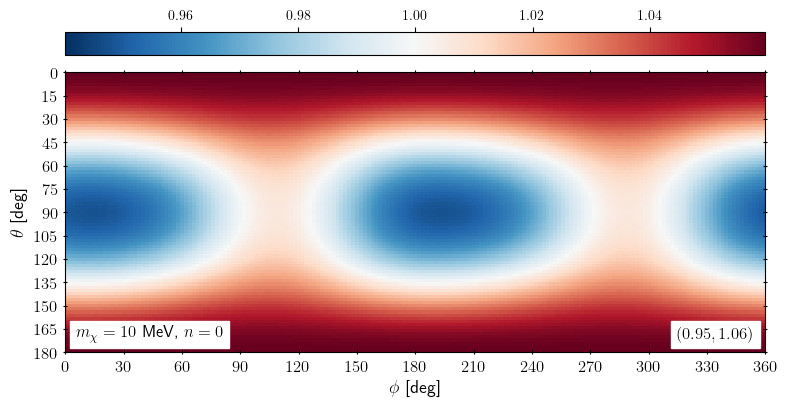

In [9]:
mX = 10
n = 0
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)
            

# ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$, $\beta={}^\circ$'.format(mX, n, beta), 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'$({:.2f}, {:.2f})$'.format(min_R, max_R), horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)


# ax1.legend(loc='lower center')
# ax1.legend(loc=(0.67, 0.03))


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)


fig.show()

## Exploring the Sphere (Daily Modulation)

Functions for a simple daily modulation excercise, to be used when the orientation of the physical sample is not important, and when the time of year (i.e. $\theta_N$) is fixed. 

The function to use is `dailyModMe`. 

In [10]:
def nhat(theta, phi):
    nx = np.sin(theta) * np.cos(phi) 
    ny = np.sin(theta) * np.sin(phi) 
    nz = np.cos(theta) 
    return np.array([nx, ny, nz])

def rotationQ(theta, phi, alpha):
    "Encodes a rotation by angle 'alpha' about the (theta,phi) unit vector."
    nx,ny,nz = nhat(theta, phi)
    axR = alpha/2 
    cosah = np.cos(alpha/2) 
    sinah = np.sin(alpha/2) 
    return qnc.array(cosah, sinah*nx, sinah*ny, sinah*nz)

def qfunc(qr, vec3d):
    return qnc.array(qr, vec3d[0], vec3d[1], vec3d[2])

def makeCone(theta_north, phi_north, phase, thetaN=(42*deg), dt_h=0.2):
    """Returns the Earth velocity unit vector vE as a function of time.
    
    theta_north, phi_north: a 2d unit vector specifying the location of the north pole 
        (in the crystal coordinate frame, where theta=0 is the "b=z" direction)
    phase: shifts the "t=0" starting position of vE
    thetaN: the angle between the DM wind and the north pole (radians)
    dt_h: the time step to use, in sidereal hours (24h = 360 deg)

    returns lists of tH,theta_E,phi_E, with angles in radians and times in sidereal hours
    """
    # north pole vector:
    northvec = nhat(theta_north, phi_north)
    # Step 1: find a starting position for vE, rotating "northvec" by thetaN about any orthogonal vector.
    eps = 0.005
    # default: define the rotation axis as orthogonal to "x":
    axis_init = np.cross(northvec, np.array([1, 0, 0]))
    # if northvec is colinear with "x", use the "y" axis instead:
    if np.linalg.norm(axis_init) < eps:
        axis_init = np.cross(northvec, np.array([0, 1, 0]))
    # rotate about axis_init by angle thetaN:
    one,theta_ai,phi_ai = cart_to_sph(axis_init)
    Q_init = rotationQ(theta_ai, phi_ai, thetaN)
    qnorth = qfunc(0., northvec)
    vE_init = rotateBy(Q_init, qnorth)

    Q_phase = rotationQ(theta_north, phi_north, phase)
    vE_0 = rotateBy(Q_phase, vE_init)

    # Step 2: rotate vE_0 about the north pole
    lenT = int(24.0 / dt_h) + 1 # include 24.0h at the end
    sid_times = [j*dt_h for j in range(lenT)]
    thetaE = []
    phiE = []
    for t in sid_times: 
        alpha = t/24 * 2*np.pi # rotation angle 
        Q_t = rotationQ(theta_north, phi_north, alpha) # rotation operator 
        qE_t = rotateBy(Q_t, vE_0) # rotated vector (as quaterion) 
        vE_t = qE_t.imag # convert back to 3d vector 
        one,theta,phi = cart_to_sph(vE_t) # convert to spherical coordinate
        thetaE += [theta]
        phiE += [phi]
    return np.array(sid_times), np.array(thetaE), np.array(phiE)

def dailyModMe(rate_intp_deg, theta_north, phi_north, phase, thetaN=(42*deg), dt_h=0.25):
    """Returns the rate as a function of time for a daily modulation analysis.

    rate_intp: interpolating function R(theta, phi), for theta and phi in degrees 
    theta_north, phi_north, phase: orientation of the sample
    thetaN: angle between "north" and the DM wind 
    dt_h: time step size, in sidereal hours

    returns the lists tH,R(tH) 
    """
    t_h, thetaE, phiE = makeCone(theta_north, phi_north, phase, thetaN=thetaN, dt_h=dt_h)
    thetaDeg = thetaE / deg 
    phiDeg = phiE / deg 
    rates_t = rate_intp_deg([[thetaDeg[j], phiDeg[j]] for j in range(len(t_h))])
    return t_h, rates_t



#

### Example: Daily Modulation at arbitrarily chosen orientation

In [11]:
"""Choose a DM model and trans-stilbene transition:"""
mX = 10
n = 0
sI_2d = 'tot' # 'tot' or 's1'
data_intp = rn_intp[(sI_2d, n, mX)]

"""Choose a crystal-frame north pole vector:"""
theta_north = 1.3
phi_north = 4.2

"""Adjust the phase, if you like:"""
phase = np.pi

"""Specify the time of year:"""
thetaN = 44*deg

# main result:
t_h, Rt = dailyModMe(data_intp, theta_north, phi_north, phase, thetaN=thetaN, dt_h=0.25)

# for plots:
t_h,thetaE,phiE = makeCone(theta_north, phi_north, phase, thetaN=thetaN, dt_h=0.25)


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/3498970374.py:40: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


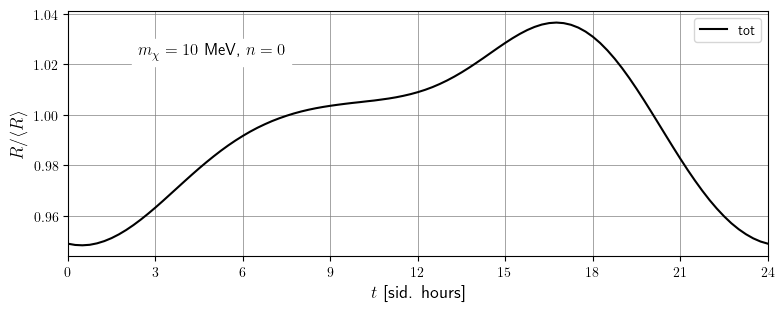

In [12]:
"""Plot R(t):"""

fig = plt.figure(figsize=[2.0*unisize,unisize])
ax2 = fig.add_axes([0,0,1,0.7], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'crimson'
# sIcolor['s1s2'] = 'cornflowerblue'
# sIcolor['s1s5'] = 'slategray'
# sIcolor['s1s8'] = 'mediumpurple'
nstyle = {'A': 'solid', 'B': 'dashed'}
sIs = ['s1', 'tot']

ax2.plot(t_h, Rt, color=sIcolor['tot'], label='tot')
# ax2.plot(tH, RtHs1, color=sIcolor['s1'], label='s1')
# mX, n label:
ax2.text(0.1, 0.8, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()

# plt.savefig('out/modRate_mX{}_n{}_initial.png'.format(mX, n), 
#             format="png", dpi=600, bbox_inches='tight')

fig.show()

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/1866602675.py:65: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/1866602675.py:105: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


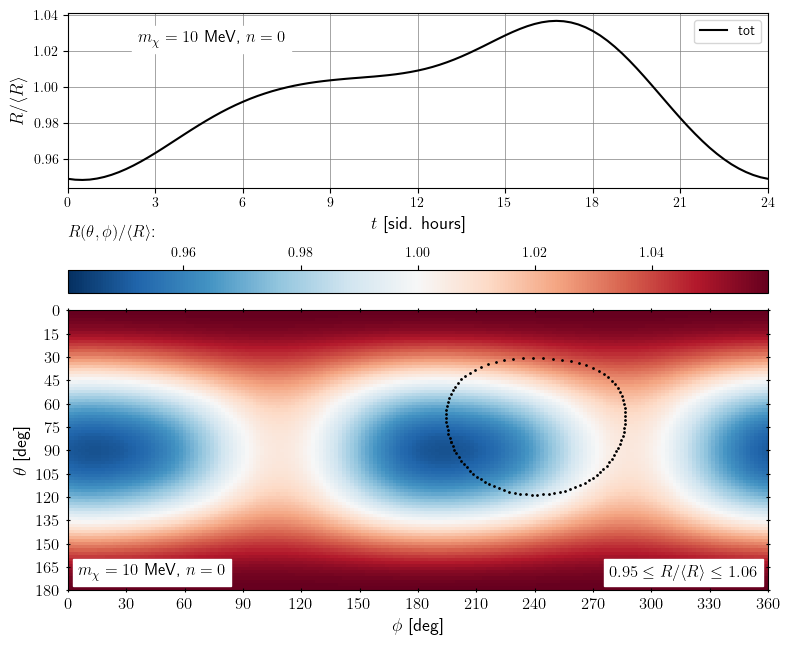

In [13]:
"""Fancy plot:"""

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)

### draw the cone:
ax1.plot(phiE/deg, thetaE/deg, 'o', color='black', markersize=1)

            
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'${:.2f} \leq R/\langle R \rangle \leq {:.2f}$'.format(min_R, max_R), 
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         # backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
# ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          # backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)

ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'crimson'
# sIcolor['s1s2'] = 'cornflowerblue'
# sIcolor['s1s5'] = 'slategray'
# sIcolor['s1s8'] = 'mediumpurple'
nstyle = {'A': 'solid', 'B': 'dashed'}
sIs = ['s1', 'tot']

ax2.plot(t_h, Rt, color=sIcolor[sI_2d], label=sI_2d)

# mX, n label:
ax2.text(0.1, 0.8, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()

# plt.savefig('out/modRate_mX{}_n{}_initial.png'.format(mX, n), 
#             format="png", dpi=600, bbox_inches='tight')

fig.show()

## Aside: Rate in events per second

The total rate depends on the detector mass, exposure time, DM cross section, and local DM density. The "rate" calculated so far is a dimensionless quantity $\mu$, independent of these factors, and scaled by some powers of $v_0 \equiv {\rm VMAX}$ and $q_0 \equiv {\rm QMAX}$. To get the number of expected events, multiply the dimensionless rate $\mu$ by a basis-dependent dimensionless exposure factor $k_0$, 
$$k_0 = N_T \rho_\chi \bar\sigma_0 \frac{v_0^2}{q_0},$$
so that the expected event rate is:
$$R = \frac{k_0}{T_{exp}} \sum_{\ell, m, m'} K^{(\ell)}_{m m'} G^{(\ell)}_{m m'}.$$

In [14]:
"""exposure factor for 1 kg of trans-stilbene, for 1 second"""
k0 = vsdm.g_k0(exp_kgyr=1./(3.15e7), mCell_g=721.0, 
               sigma0_cm2=1e-34, rhoX_GeVcm3=0.4, 
               v0=Vbasis['u0'], q0=Qbasis['u0'])

"""angular averages <R> for each model:"""
print('rates in Hz:')
for sI_m_n in keylist:
    K000 = rates[sI_m_n].vecK[0]
    print('{}: {}'.format(sI_m_n, K000*k0))

rates in Hz:
('s1', 0, 10): 0.6920830630751752
('s1', 2, 10): 0.17602764241302818
('tot', 0, 10): 0.9752011213801651
('tot', 2, 10): 0.241691538191806


# Daily Modulation in Fermilab

Using earthspeed to find $v_E(t)$ in the co-rotating lab frame, then converting it to $\theta$ and $\phi$ for a rotated detector. 

In [15]:
"""(earthspeed) Example (now): altitude and azimuth for a particular place on Earth"""
date = dts.datetime.now(dts.timezone.utc)
wind = Windfinder([date])
print('Example datetime (UTC):', date)
ra, dec = wind.RAdec[0]
print('Sky position: RA, dec [deg] = ({:.2f}, {:.2f})'.format(ra, dec))

fermilab = EarthLocation(lat='41.838', lon='-88.262', height=0.*u.m)
# snolab = EarthLocation(lat='46.472', lon='-81.188', height=0.*u.m)

altaz = wind.vE_altAz(fermilab)
print('Wilson Hall, Fermilab:')
print('\t vE [km/s]: {:.2f} \t alt [deg]: {:.2f} \t az [deg]: {:.2f}'.format(altaz[0][0], altaz[0][1], altaz[0][2]))

# # Can also use astropy object Windfinder.galactic directly:
# vE_icrs = wind.galactic[0].transform_to(ICRS())
# vE_icrs.dec

Example datetime (UTC): 2025-09-22 19:46:33.739305+00:00
Sky position: RA, dec [deg] = (320.54, 52.70)
Wilson Hall, Fermilab:
	 vE [km/s]: 247.22 	 alt [deg]: 21.97 	 az [deg]: 37.63


In [16]:
"""Daily modulation for [ALL 2025] at [Fermilab].
    Default "t = 0" is 12:00am CDT on Jan 1, 2025 (UTC -5). 
    This can be changed by redefining 'midnight' (e.g. to CST).
"""

nDays = 365

cdt = dts.timezone(dts.timedelta(hours=-5), name='CDT')
midnight = dts.datetime(2025, 1, 1, hour=0, tzinfo=cdt)
midnight.astimezone(dts.timezone.utc)

# Sampling density:
dt_per_hour = 5
dt_hours = 1/dt_per_hour
dt = dt_hours * dts.timedelta(hours=1)
obstimes = [midnight + dt * j for j in range(nDays*24*dt_per_hour+1)]
location = fermilab

tH = np.zeros(len(obstimes))
vEs = np.zeros(len(obstimes))
alts = np.zeros(len(obstimes))
azs = np.zeros(len(obstimes))

#Get the Earth velocity vector:
vE_ijk = []
for j,t in enumerate(obstimes):
    vE, alt, az = ethp.vE_AltAz(t, location)
    tH[j] = dt_hours*j 
    vEs[j] = vE
    alts[j] = alt
    azs[j] = az
    th0 = (90 - alt) * np.pi/180 
    ph0 = (-az) * np.pi/180 
    v_x = vE * np.sin(th0) * np.cos(ph0)
    v_y = vE * np.sin(th0) * np.sin(ph0)
    v_z = vE * np.cos(th0)
    vE_ijk += [[0, v_x, v_y, v_z]]
vE_ijk = qnc.array(vE_ijk)

print('altitude min and max [degrees]: {:.3f}, {:.3f}'.format( alts.min(), alts.max()))


altitude min and max [degrees]: -6.442, 89.948


## Cube Geometry

This section uses the indexing data from Dane to infer the crystal sample geometry. Cubes 2, 5, and 6 have more reliable normal vectors, i.e. they are more orthogonal than cubes 1, 3 and 4. 

We define the lab-frame cube orientation by two crystal-frame vectors: 
* `up`: this face of the cube points towards the zenith, at the lab location [Fermilab] defined above.
* `face`: this cube face points along the horizon towards the CCD. It does not matter if `face` is not orthogonal to `up`: the (up, face) procedure simply rotates `face` until its projection on the horizon points in the correct direction.
* $\gamma$: this parameter controls the orientation of the CCD. $\gamma = 0$ puts the CCD on the north horizon (facing south), $\gamma = 90^\circ$ puts the CCD on the west horizon (facing east), etc.

So, there are two ways to change the horizontal alignment of a crystal: by redefining `face`, or by changing `gamma`. 

In [17]:
"""Cube normal vectors: provided in (a, b, c) basis."""

#unit vectors or not?
lenA = 12.4057
lenB = 5.7411
lenC = 15.7978
angb = 111.8510 * np.pi/180

# (x, y, z) basis:
hatB = np.array([0, 0, 1]) # b = z
hatC = np.array([1, 0, 0]) # c = x
hatA = np.array([np.cos(angb), np.sin(angb), 0]) # a ~ y

vecA = lenA * hatA
vecB = lenB * hatB
vecC = lenC * hatC

# data from Dane:
cubeface = {} 
cubeface['1A'] = np.array([-1, -1, 6])
cubeface['1B'] = np.array([7, 0, -2])
cubeface['1C'] = np.array([1, 5, 5])

cubeface['2A'] = np.array([0, 0, 1])
cubeface['2B'] = np.array([8, -1, 3])
cubeface['2C'] = np.array([3, 6, 2])

cubeface['3A'] = np.array([-9, 0, 4])
cubeface['3B'] = np.array([0, 1, 7])
cubeface['3C'] = np.array([-1, 5, -3])

cubeface['4A'] = np.array([0, 0, 1])
cubeface['4B'] = np.array([5, 1, 3])
cubeface['4C'] = np.array([-3, 5, 4])

# changing (c,b) order to get right-handed systems:
cubeface['5A'] = np.array([0, 0, 1])
cubeface['5C'] = np.array([2, 0, 1])
cubeface['5B'] = np.array([1, -4, 0])

cubeface['6A'] = np.array([-1, 1, 8])
cubeface['6C'] = np.array([-9, -1, -3])
cubeface['6B'] = np.array([-2, 8, -3])

# convert the [a, b, c] data into a normal vector for face 'cface':
def getUvec(cface, unit=True):
    na, nb, nc = cface
    if unit:
        uvec = na * hatA + nb * hatB + nc * hatC # unit vectors
    else:
        uvec = na * vecA + nb * vecB + nc * vecC # vectors of different lengths
    uvec = uvec / np.linalg.norm(uvec) # normalize length to 1
    return uvec
    
uvecs = {}
uhats = {}
for key,cface in cubeface.items():
    uvec = getUvec(cface, unit=True)
    uvecs[key] = uvec
    usph = vsdm.cart_to_sph(uvec)
    uhats[key] = (usph[1], usph[2]) # theta_u, phi_u
    # print(key, uvecs[key], uhats[key])

# print("Cube angles assuming (a, b, c) vectors of length (12.4, 5.7, 15.8):")
print("Cube angles assuming (a, b, c) vectors of length (1, 1, 1):")
for ic in range(1, 7):
    uA = uvecs[str(ic)+'A']
    uB = uvecs[str(ic)+'B']
    uC = uvecs[str(ic)+'C']
    dAB = uA @ uB
    dAC = uA @ uC
    dBC = uB @ uC
    volume = (np.cross(uA, uB) @ uC)
    # print('{}:'.format(ic), dAB, dAC, dBC)
    thAB = np.arccos(dAB) * 180/np.pi
    thAC = np.arccos(dAC) * 180/np.pi
    thBC = np.arccos(dBC) * 180/np.pi
    print('{}.'.format(ic), 'vol: {:.3f}'.format(volume), 'AB: {:.1f}'.format(thAB), 'AC: {:.1f}'.format(thAC), 'BC: {:.1f}'.format(thBC))
    
#    
#

Cube angles assuming (a, b, c) vectors of length (1, 1, 1):
1. vol: 0.616 AB: 133.0 AC: 58.2 BC: 106.2
2. vol: 0.947 AB: 89.8 AC: 82.4 BC: 72.9
3. vol: 0.713 AB: 49.2 AC: 100.5 BC: 109.3
4. vol: 0.693 AB: 76.5 AC: 48.2 BC: 93.2
5. vol: 0.961 AB: 95.2 AC: 82.2 BC: 77.8
6. vol: 0.976 AB: 97.3 AC: 82.2 BC: 84.6


In [18]:
cubes = [i for i in range(1, 7)]
# orthogonal bases (0..5), six for each cube
bases = {}
orth_ixs = []
for cube in cubes:
    orth_ix = (cube)
    orth_ixs += [orth_ix]
    not_orth = np.array([uvecs[str(cube)+lbl] for lbl in ['A', 'B', 'C']])
    bases[orth_ix] = not_orth
    bases[(cube, 'A')] = not_orth[0]
    bases[(cube, 'B')] = not_orth[1]
    bases[(cube, 'C')] = not_orth[2]
    bases[(cube, '-A')] = not_orth[0] * (-1)
    bases[(cube, '-B')] = not_orth[1] * (-1)
    bases[(cube, '-C')] = not_orth[2] * (-1)


In [19]:
print(bases[(2)])
print(bases[(3, '-A')])

[[ 1.          0.          0.        ]
 [ 0.00299598  0.9910483  -0.13347022]
 [ 0.13237982  0.41725108  0.89909795]]
[-0.66056511  0.75076876 -0.        ]


At this point, the notebook `cubeRotate` introduces the function `cubify` to generate sets of orthogonal normal vectors for each cube. We can skip this: all we need is to define suitable `up` and `face` vectors, whether or not they align with a facet of the actual cube samples. 

In [20]:
"""Example 1: initial orientation. 
    z-hat points up, x-hat points north
"""
Uvec = [0, 0, 1] # point UP
Fvec = [1, 0, 0] # point AT CCD
gamma = 0. # azimuthal angle of CCD
Rcrl = getRcrl(Uvec, Fvec, gamma)
print('Rotation operator: Q =', Rcrl)
vEcell = rotateBy(1/Rcrl, vE_ijk)

# convert to spherical coordinates
thetaE = []
phiE = []
for vE in vEcell:
    v,th,ph = vsdm.cart_to_sph(vE.vector)
    thetaE += [th]
    phiE += [ph]
thetaEd = 180/np.pi * np.array(thetaE)
phiEd = 180/np.pi * np.array(phiE)

# get R(t) 
n = 0

data_tot = rn_intp[('tot', n, mX_eg)]
data_s1 = rn_intp[('s1', n, mX_eg)]
RtH = [data_tot([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
RtHs1 = [data_s1([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
# get fRMS 
f_tot = fRMS(RtH)
f_s1 = fRMS(RtHs1)
print('fRMS: {:.4g} (tot) \t {:.4g} (s1 only)'.format( f_tot, f_s1))
chi2_tot = chi2norm(RtH)
chi2_s1 = chi2norm(RtHs1)
print('chi2: {:.4g} (tot) \t {:.4g} (s1 only)'.format( chi2_tot, chi2_s1))


Rotation operator: Q = [1. 0. 0. 0.]
fRMS: 0.03825 (tot) 	 0.03101 (s1 only)
chi2: 0.001462 (tot) 	 0.0009614 (s1 only)


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/2930415557.py:80: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/2930415557.py:128: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


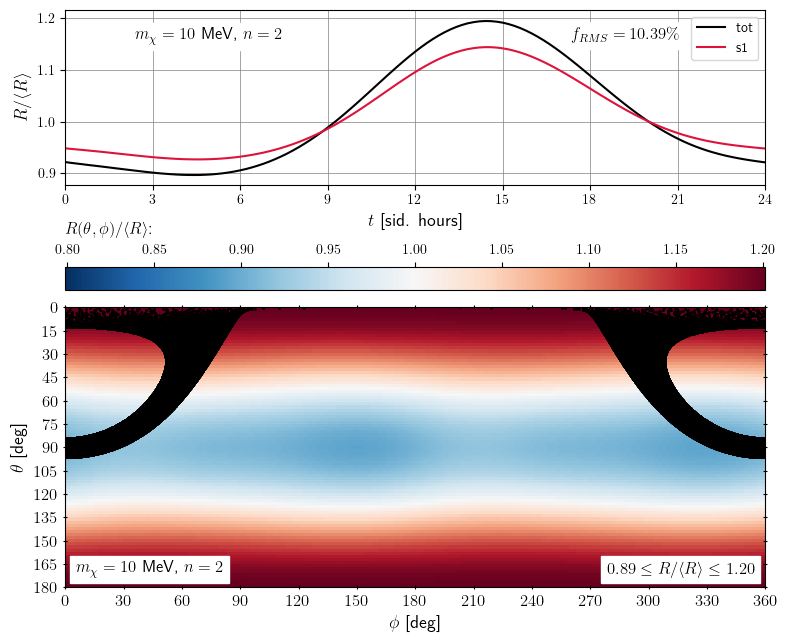

In [21]:
mX = mX_eg
n = 2
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

# get R(t) 
data_tot = rn_intp[('tot', n, mX)]
data_s1 = rn_intp[('s1', n, mX)]
RtH = [data_tot([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
RtHs1 = [data_s1([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
# get fRMS 
f_tot = fRMS(RtH)
f_s1 = fRMS(RtHs1)
# print(f_tot, f_s1)
chi2_tot = chi2norm(RtH)
chi2_s1 = chi2norm(RtHs1)
# print(chi2_tot, chi2_s1)

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)

### draw the cone:
ax1.plot(phiEd, thetaEd, 'o', color='black', markersize=1)

            
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'${:.2f} \leq R/\langle R \rangle \leq {:.2f}$'.format(min_R, max_R), 
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         # backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
# ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          # backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)

ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'crimson'
# sIcolor['s1s2'] = 'cornflowerblue'
# sIcolor['s1s5'] = 'slategray'
# sIcolor['s1s8'] = 'mediumpurple'
nstyle = {'A': 'solid', 'B': 'dashed'}
sIs = ['s1', 'tot']

ax2.plot(tH, RtH, color=sIcolor['tot'], label='tot')
ax2.plot(tH, RtHs1, color=sIcolor['s1'], label='s1')

# mX, n label:
ax2.text(0.1, 0.8, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)
# fRMS score:
ax2.text(0.8, 0.9, r'$f_{RMS} = \,$' + r'${:.2f}\%$'.format(f_tot*100), 
         horizontalalignment='center',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()

# plt.savefig('out/modRate_mX{}_n{}_initial.png'.format(mX, n), 
#             format="png", dpi=600, bbox_inches='tight')

fig.show()

In [22]:
"""Example 2:  
    y-hat points up, z-hat points northwest
"""
Uvec = [0, 1, 0] # point UP
Fvec = [0, 0, 1] # point AT CCD
gamma = 45*deg # azimuthal angle of CCD
Rcrl = getRcrl(Uvec, Fvec, gamma)
print('Rotation operator: Q =', Rcrl)
vEcell = rotateBy(1/Rcrl, vE_ijk)

# convert to spherical coordinates
thetaE = []
phiE = []
for vE in vEcell:
    v,th,ph = vsdm.cart_to_sph(vE.vector)
    thetaE += [th]
    phiE += [ph]
thetaEd = 180/np.pi * np.array(thetaE)
phiEd = 180/np.pi * np.array(phiE)

# get R(t) 
n = 0

data_tot = rn_intp[('tot', n, mX_eg)]
data_s1 = rn_intp[('s1', n, mX_eg)]
RtH = [data_tot([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
RtHs1 = [data_s1([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
# get fRMS 
f_tot = fRMS(RtH)
f_s1 = fRMS(RtHs1)
print('fRMS: {:.4g} (tot) \t {:.4g} (s1 only)'.format( f_tot, f_s1))
chi2_tot = chi2norm(RtH)
chi2_s1 = chi2norm(RtHs1)
print('chi2: {:.4g} (tot) \t {:.4g} (s1 only)'.format( chi2_tot, chi2_s1))


Rotation operator: Q = [0.27059805 0.27059805 0.65328148 0.65328148]
fRMS: 0.02763 (tot) 	 0.02264 (s1 only)
chi2: 0.0007664 (tot) 	 0.0005145 (s1 only)


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/84967733.py:80: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/84967733.py:128: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


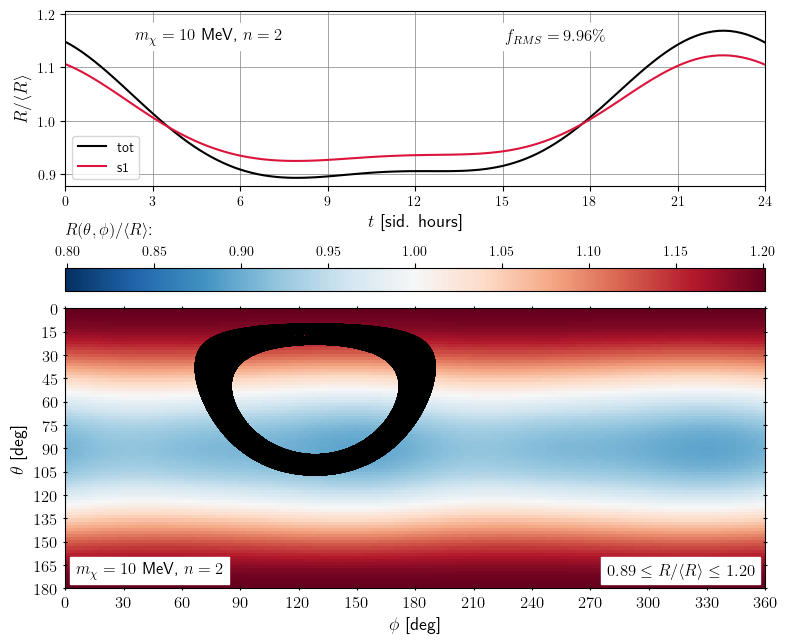

In [24]:
mX = mX_eg
n = 2
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

# get R(t) 
data_tot = rn_intp[('tot', n, mX)]
data_s1 = rn_intp[('s1', n, mX)]
RtH = [data_tot([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
RtHs1 = [data_s1([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
# get fRMS 
f_tot = fRMS(RtH)
f_s1 = fRMS(RtHs1)
# print(f_tot, f_s1)
chi2_tot = chi2norm(RtH)
chi2_s1 = chi2norm(RtHs1)
# print(chi2_tot, chi2_s1)

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)

### draw the cone:
ax1.plot(phiEd, thetaEd, 'o', color='black', markersize=1)

            
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'${:.2f} \leq R/\langle R \rangle \leq {:.2f}$'.format(min_R, max_R), 
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         # backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
# ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          # backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)

ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'crimson'
# sIcolor['s1s2'] = 'cornflowerblue'
# sIcolor['s1s5'] = 'slategray'
# sIcolor['s1s8'] = 'mediumpurple'
nstyle = {'A': 'solid', 'B': 'dashed'}
sIs = ['s1', 'tot']

ax2.plot(tH, RtH, color=sIcolor['tot'], label='tot')
ax2.plot(tH, RtHs1, color=sIcolor['s1'], label='s1')

# mX, n label:
ax2.text(0.1, 0.9, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)
# fRMS score:
ax2.text(0.7, 0.9, r'$f_{RMS} = \,$' + r'${:.2f}\%$'.format(f_tot*100), 
         horizontalalignment='center',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()

plt.savefig('out/modRate_mX{}_n{}_FNL.png'.format(mX, n), 
            format="png", dpi=600, bbox_inches='tight')

fig.show()

## Examples for Fermilab

In [25]:
def thetaphi_cell(vEq_crl, up_vec, face_vec, gamma):
    Rcrl = getRcrl(up_vec, face_vec, gamma)
    vEcell = rotateBy(1/Rcrl, vEq_crl)
    
    # convert to spherical coordinates
    thetaE = []
    phiE = []
    for vE in vEcell:
        v,th,ph = vsdm.cart_to_sph(vE.vector)
        thetaE += [th]
        phiE += [ph]
    return np.array(thetaE), np.array(phiE) #in radians


In [26]:
"""Specific cube orientations:"""
upfaceG0 = {2:('A','C'), 5:('B','A'), 6:('A','B')}

In [27]:
gamma = 45 * deg
n = 2
model = ('tot', n, mX_eg) # (sI, n, mX)

rate_thphd = rn_intp[model]

thetad_yr = {}
phid_yr = {}
Rt_yr = {}
for cube,uf in upfaceG0.items():
    t0 = time.time()
    l_up, l_face = uf 
    upvec = bases[(cube, l_up)]
    facevec = bases[(cube, l_face)]
    thE, phE = thetaphi_cell(vE_ijk, upvec, facevec, gamma)
    thD = 180/np.pi * thE
    phD = 180/np.pi * phE
    thph_ix = cube # use cube=2,5,6 as the dict label
    thetad_yr[thph_ix] = thD
    phid_yr[thph_ix] = phD
    RtH = [rate_thphd([thD[i], phD[i]])[0] for i in range(len(thD))]
    Rt_yr[thph_ix] = np.array(RtH)
    # print(cube, time.time() - t0)
        

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/733014026.py:30: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


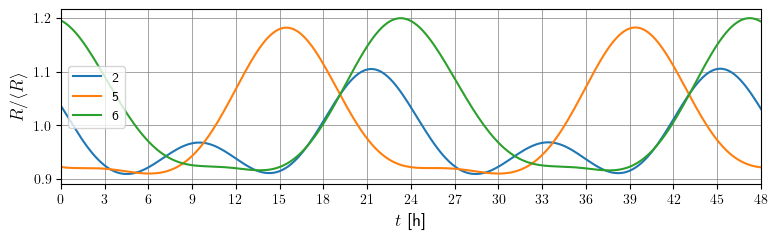

In [28]:
fig = plt.figure(figsize=[2.0*unisize,unisize])
gammaD = int(gamma*180/np.pi)

makeCSV = False

day_i = 0
day_f = 1

ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')

ax2.set_xlabel(r'$t$ [h]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=True)
ax2.set_xlim([24*day_i,24*(day_f+1)])
ax2.set_xticks([t for t in range(24*day_i, 24*(day_f+1)+1, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for cube in Rt_yr.keys():
    RtHa = Rt_yr[cube]
    if makeCSV:
        np.savetxt('out/RtH_g{}_n{}_cube{}.csv'.format(gammaD, n, cube), RtHa)
        np.savetxt('out/tH_days{}.csv'.format(nDays), tH)
    ax2.plot(tH, RtHa, label=str(cube))

ax2.legend()

plt.savefig('out/year_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

## Last Example 

Using the Fermilab (up, face) orientation for cube 2, with $\gamma = 45^\circ$. 

In [29]:
"""Example 3: (UP, FACE) from cube 2 at gamma = 45 deg. """

Uvec = bases[(2, 'A')] # point UP
Fvec = bases[(2, 'C')] # point AT CCD
gamma = 45*deg # azimuthal angle of CCD

n = 2

Rcrl = getRcrl(Uvec, Fvec, gamma)
print('Rotation operator: Q =', Rcrl)
vEcell = rotateBy(1/Rcrl, vE_ijk)
# convert to spherical coordinates
thetaE = []
phiE = []
for vE in vEcell:
    v,th,ph = vsdm.cart_to_sph(vE.vector)
    thetaE += [th]
    phiE += [ph]
thetaEd = 180/np.pi * np.array(thetaE)
phiEd = 180/np.pi * np.array(phiE)

# get R(t) 

data_tot = rn_intp[('tot', n, mX_eg)]
data_s1 = rn_intp[('s1', n, mX_eg)]
RtH = [data_tot([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
RtHs1 = [data_s1([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
# get fRMS 
f_tot = fRMS(RtH)
f_s1 = fRMS(RtHs1)
print('fRMS: {:.4g} (tot) \t {:.4g} (s1 only)'.format( f_tot, f_s1))
chi2_tot = chi2norm(RtH)
chi2_s1 = chi2norm(RtHs1)
print('chi2: {:.4g} (tot) \t {:.4g} (s1 only)'.format( chi2_tot, chi2_s1))


Rotation operator: Q = [-0.40504863  0.57959953  0.40504863  0.57959953]
fRMS: 0.06765 (tot) 	 0.04706 (s1 only)
chi2: 0.004484 (tot) 	 0.002184 (s1 only)


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/4069194013.py:80: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  fig.colorbar(mappable=clmapZ,
/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_36712/4069194013.py:128: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


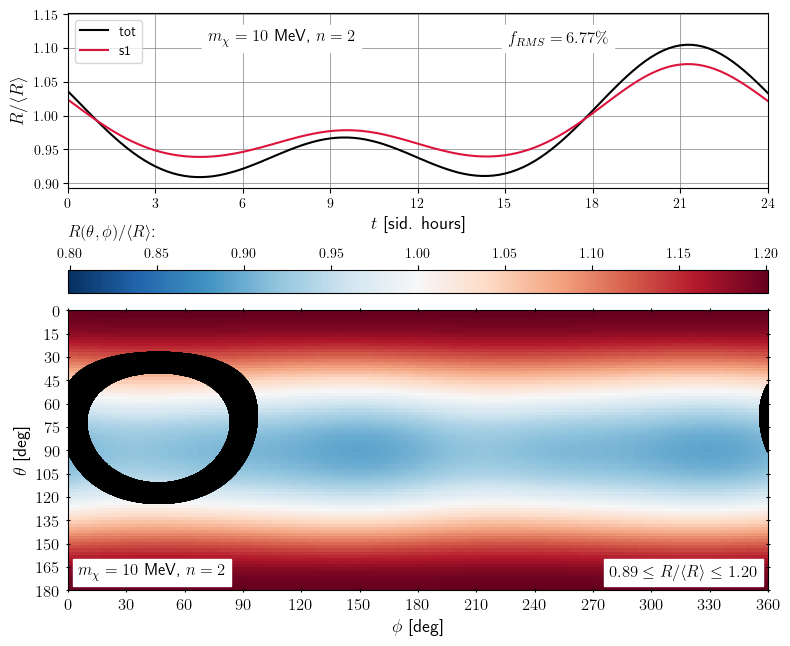

In [30]:
mX = mX_eg
n = 2
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

# get R(t) 
data_tot = rn_intp[('tot', n, mX)]
data_s1 = rn_intp[('s1', n, mX)]
RtH = [data_tot([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
RtHs1 = [data_s1([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
# get fRMS 
f_tot = fRMS(RtH)
f_s1 = fRMS(RtHs1)
# print(f_tot, f_s1)
chi2_tot = chi2norm(RtH)
chi2_s1 = chi2norm(RtHs1)
# print(chi2_tot, chi2_s1)

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=True)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=True)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)

### draw the cone:
ax1.plot(phiEd, thetaEd, 'o', color='black', markersize=1)

            
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.985, 0.035, r'${:.2f} \leq R/\langle R \rangle \leq {:.2f}$'.format(min_R, max_R), 
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         # backgroundcolor='white',
         transform=ax1.transAxes, usetex=True)
# ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          # backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)


fig.colorbar(mappable=clmapZ, 
             orientation='horizontal', location='top', 
             aspect=30)

ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'crimson'
# sIcolor['s1s2'] = 'cornflowerblue'
# sIcolor['s1s5'] = 'slategray'
# sIcolor['s1s8'] = 'mediumpurple'
nstyle = {'A': 'solid', 'B': 'dashed'}
sIs = ['s1', 'tot']

ax2.plot(tH, RtH, color=sIcolor['tot'], label='tot')
ax2.plot(tH, RtHs1, color=sIcolor['s1'], label='s1')

# mX, n label:
ax2.text(0.2, 0.9, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)
# fRMS score:
ax2.text(0.7, 0.9, r'$f_{RMS} = \,$' + r'${:.2f}\%$'.format(f_tot*100), 
         horizontalalignment='center',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()

# plt.savefig('out/modRate_mX{}_n{}_initial.png'.format(mX, n), 
#             format="png", dpi=600, bbox_inches='tight')

fig.show()

## Rate as function of Earth velocity vector

Here is a function that returns $R(\hat v_E)$, which is equivalent to $R(\mathcal R)$ for $\mathcal R \in SO(3)$ if the lab frame DM velocity distribution is azimuthally symmetric. This way, $\vec v_E(t)$ can be generated under any assumptions, and converted into a list of $\theta_v$ and $\phi_v$ angles. The function `R_vEhat` takes the keyword argument `key`, which should be one of the DM models for which the interpolating function `rn_intp` is defined. 

In [31]:
print([key for key in rn_intp.keys()])

[('s1', 0, 10), ('s1', 2, 10), ('tot', 0, 10), ('tot', 2, 10)]


In [32]:
def R_vEhat(theta_t, phi_t, key=('tot', 0, 10)):
    # theta and phi in radians 
    # thetaDs = np.array(thetas)/deg 
    # phiDs = np.array(phis)/deg
    thph_t = np.array([[theta_t[j], phi_t[j]] for j in range(len(theta_t))])
    # convert to degrees for interpolator:
    R_intp = rn_intp[key](thph_t/deg)
    return R_intp
    

In [33]:
theta_t = [0, 0.1, 0.5, 1.3]
phi_t = [0, 0.25, 0.5, 0.25]
R_vEhat(theta_t, phi_t, key=('tot', 2, 10))

array([1.20104022, 1.19781401, 1.13149351, 0.93268212])